In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import random

from tensorflow.keras.preprocessing.image import load_img


In [25]:
import os
import pandas as pd

train_path = r"C:\Users\HP\Downloads\archive (11)\train"

input_path = []
label = []

for class_name in ['rose', 'sunflower']:

    for path in os.listdir(os.path.join(train_path, class_name)):

        if class_name == 'rose':
            label.append(0)
        else:
            label.append(1)

        input_path.append(
            os.path.join(train_path, class_name, path)
        )

In [26]:
df = pd.DataFrame({
    'images': input_path,
    'label': label
})

In [27]:
df.head()

,images,label
0,C:\Users\HP\Downloads\archive (11)\train\rose\...,0
1,C:\Users\HP\Downloads\archive (11)\train\rose\...,0
2,C:\Users\HP\Downloads\archive (11)\train\rose\...,0
3,C:\Users\HP\Downloads\archive (11)\train\rose\...,0
4,C:\Users\HP\Downloads\archive (11)\train\rose\...,0


In [28]:
df['label'].value_counts()

label
0    497
1    495
Name: count, dtype: int64

In [29]:
for i in df['images']:
    if '.jpg' not in i:
        print(i)

In [30]:
import PIL

l = []

for image in df['images']:
    try:
        img = PIL.Image.open(image)
    except:
        l.append(image)

In [31]:
df = df[~df['images'].isin(l)].reset_index(drop=True)

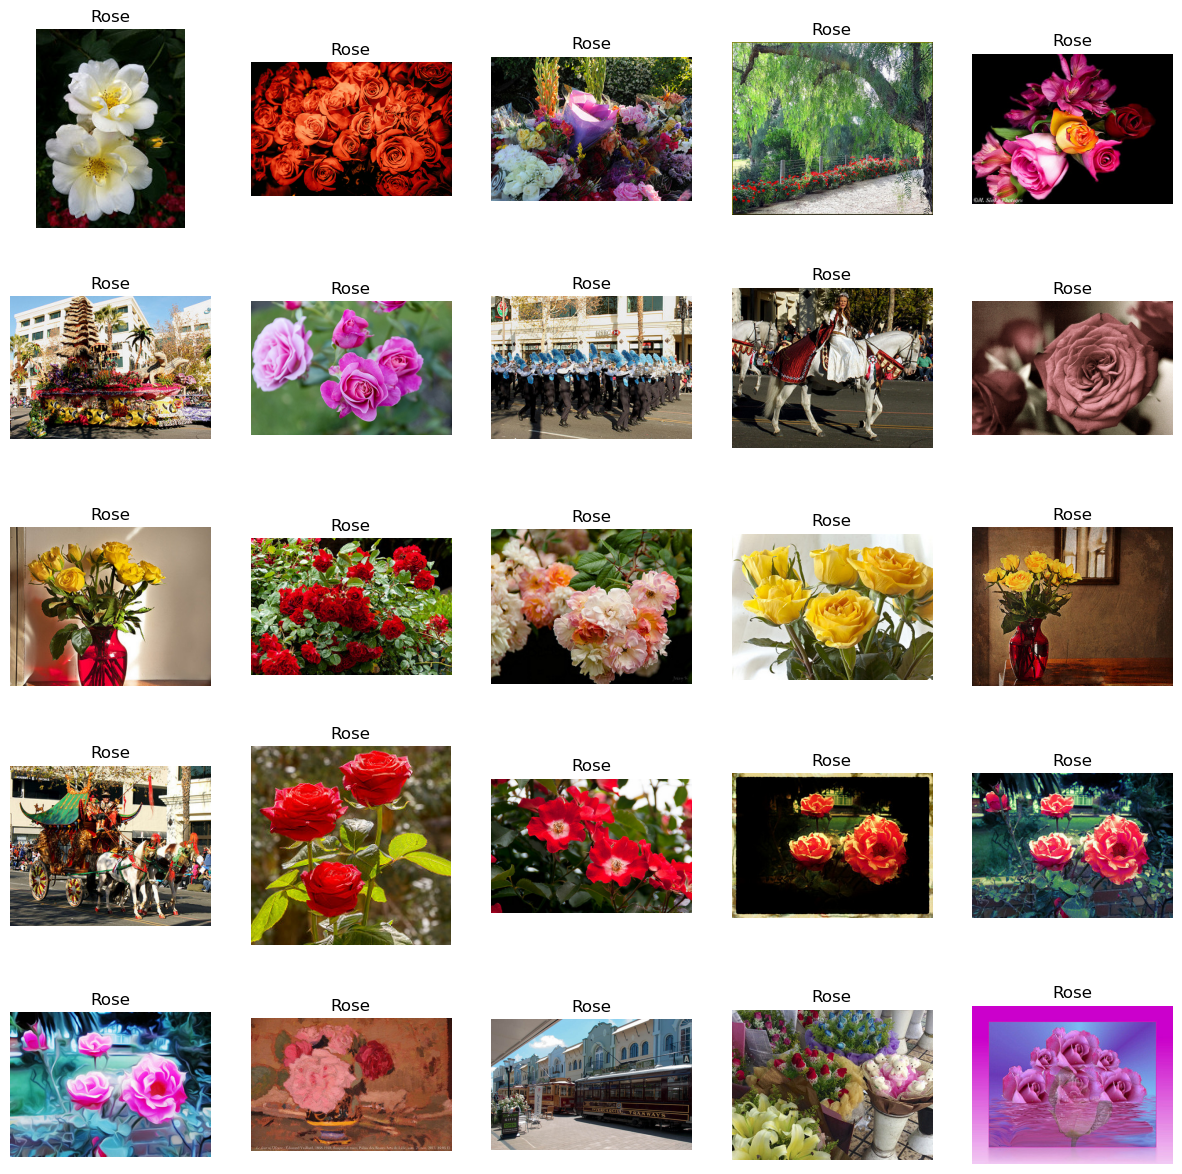

In [32]:
plt.figure(figsize=(15,15))

temp = df[df['label'] == 0]['images']

files = temp[:25]

for index, file in enumerate(files):
    plt.subplot(5,5,index+1)

    img = load_img(file)
    img = np.array(img)

    plt.imshow(img)
    plt.title("Rose")
    plt.axis("off")

plt.show()

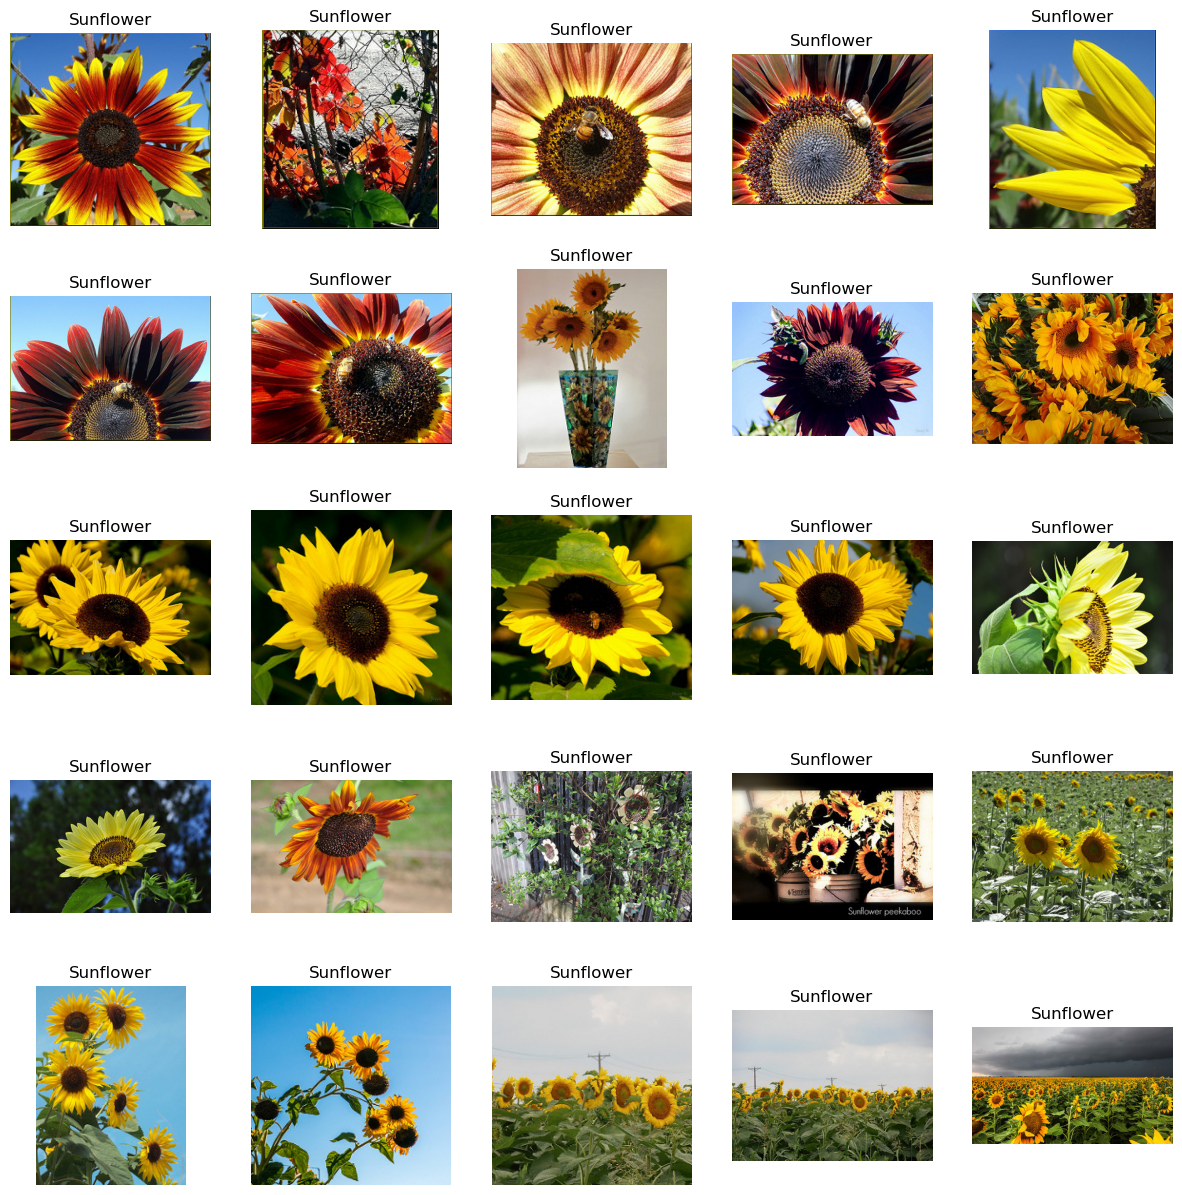

In [33]:
plt.figure(figsize=(15,15))

temp = df[df['label'] == 1]['images']

files = temp[:25]

for index, file in enumerate(files):
    plt.subplot(5,5,index+1)

    img = load_img(file)
    img = np.array(img)

    plt.imshow(img)
    plt.title("Sunflower")
    plt.axis("off")

plt.show()

In [34]:
df['label'] = df['label'].astype('str')

In [36]:
df.head()


,images,label
0,C:\Users\HP\Downloads\archive (11)\train\rose\...,0
1,C:\Users\HP\Downloads\archive (11)\train\rose\...,0
2,C:\Users\HP\Downloads\archive (11)\train\rose\...,0
3,C:\Users\HP\Downloads\archive (11)\train\rose\...,0
4,C:\Users\HP\Downloads\archive (11)\train\rose\...,0


In [35]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(
    df,
    test_size=0.2,
    random_state=42
)

In [38]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_generator = ImageDataGenerator(
    rescale = 1./255,  # normalization of images
    rotation_range = 40, # augmention of images to avoid overfitting
    shear_range = 0.2,
    zoom_range = 0.2,
    horizontal_flip = True,
    fill_mode = 'nearest'
)

val_generator = ImageDataGenerator(rescale = 1./255)

train_iterator = train_generator.flow_from_dataframe(
    train,
    x_col='images',
    y_col='label',
    target_size=(128,128),
    batch_size=32,
    class_mode='binary'
)

val_iterator = val_generator.flow_from_dataframe(
    test,
    x_col='images',
    y_col='label',
    target_size=(128,128),
    batch_size=32,
    class_mode='binary'
)

Found 793 validated image filenames belonging to 2 classes.
Found 199 validated image filenames belonging to 2 classes.


In [39]:
from keras import Sequential
from keras.layers import Conv2D, MaxPool2D, Flatten, Dense

model = Sequential([
    Conv2D(16, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPool2D((2,2)),

    Conv2D(32, (3,3), activation='relu'),
    MaxPool2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPool2D((2,2)),

    Flatten(),

    Dense(512, activation='relu'),
    Dense(1, activation='sigmoid')
])

C:\Users\HP\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [40]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 126, 126, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 61, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 12544)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │       6,423,040 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             513 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,447,137 (24.59 MB)

 Trainable params: 6,447,137 (24.59 MB)

 Non-trainable params: 0 (0.00 B)

In [41]:
history = model.fit(
    train_iterator,
    epochs=10,
    validation_data=val_iterator
)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 20s 634ms/step - accuracy: 0.7339 - loss: 0.5819 - val_accuracy: 0.9045 - val_loss: 0.2896
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 521ms/step - accuracy: 0.8436 - loss: 0.3362 - val_accuracy: 0.8995 - val_loss: 0.2825
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 518ms/step - accuracy: 0.8802 - loss: 0.2897 - val_accuracy: 0.9347 - val_loss: 0.2290
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 516ms/step - accuracy: 0.8966 - loss: 0.2513 - val_accuracy: 0.8392 - val_loss: 0.3258
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 506ms/step - accuracy: 0.8991 - loss: 0.2555 - val_accuracy: 0.9045 - val_loss: 0.2314
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 506ms/step - accuracy: 0.9042 - loss: 0.2326 - val_accuracy: 0.8995 - val_loss: 0.2909
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 512ms/step - accuracy: 0.9042 - loss: 0.2226 - val_accuracy: 0.9397 - val_loss: 0.1738
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 533ms/step - accuracy: 0.9256 - loss: 0.1999 - val_accu

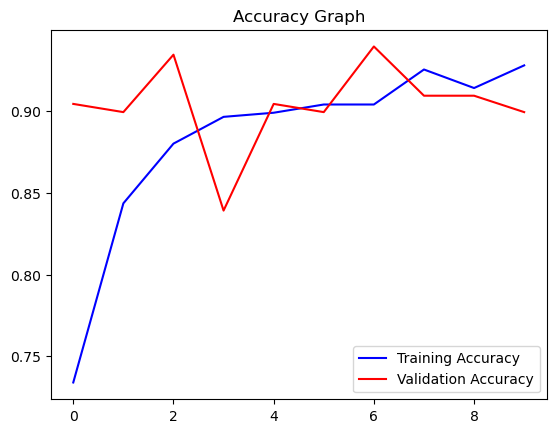

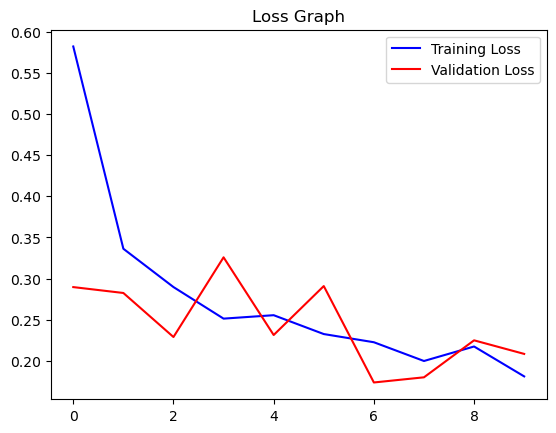

In [42]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs = range(len(acc))

plt.plot(epochs, acc, 'b', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r', label='Validation Accuracy')
plt.title('Accuracy Graph')
plt.legend()
plt.figure()

loss = history.history['loss']
val_loss = history.history['val_loss']
plt.plot(epochs, loss, 'b', label='Training Loss')
plt.plot(epochs, val_loss, 'r', label='Validation Loss')
plt.title('Loss Graph')
plt.legend()
plt.show()

In [50]:
import os

rose_folder = r"C:\Users\HP\Downloads\archive (11)\train\rose"
filenames = os.listdir(rose_folder)
print(filenames[:5])  # shows the first 5 filenames so you can see the naming pattern

image_path = os.path.join(rose_folder, filenames[0])  # picks the first image automatically
print(image_path)

['10090824183_d02c613f10_m.jpg', '10503217854_e66a804309.jpg', '10894627425_ec76bbc757_n.jpg', '11102341464_508d558dfc_n.jpg', '11233672494_d8bf0a3dbf_n.jpg']
C:\Users\HP\Downloads\archive (11)\train\rose\10090824183_d02c613f10_m.jpg


In [51]:
img = load_img(image_path, target_size=(128, 128))
img = np.array(img)
img = img / 255.0
img = img.reshape(1, 128, 128, 3)

pred = model.predict(img)

if pred[0] > 0.5:
    label = 'Sunflower'
else:
    label = 'Rose'

print(label)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 505ms/step
Rose


In [52]:
import os

sunflower_folder = r"C:\Users\HP\Downloads\archive (11)\train\sunflower"
filenames = os.listdir(sunflower_folder)
print(filenames[:5])  # peek at the first 5 filenames

image_path = os.path.join(sunflower_folder, filenames[0])  # picks the first image automatically
print(image_path)

img = load_img(image_path, target_size=(128, 128))
img = np.array(img)
img = img / 255.0
img = img.reshape(1, 128, 128, 3)

pred = model.predict(img)

if pred[0] > 0.5:
    label = 'Sunflower'
else:
    label = 'Rose'

print(label)

['10386503264_e05387e1f7_m.jpg', '10386522775_4f8c616999_m.jpg', '10386525005_fd0b7d6c55_n.jpg', '10386525695_2c38fea555_n.jpg', '10386540106_1431e73086_m.jpg']
C:\Users\HP\Downloads\archive (11)\train\sunflower\10386503264_e05387e1f7_m.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
Sunflower
